In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from accelerate.test_utils.testing import get_backend
from core.models import LinearRegression
from core.callbacks import WandBCallback
from lightning.pytorch.loggers import WandbLogger
from lightning import Trainer
from core.data import FullBatchDataModule
from core.estimators import BiasWithMSE
from core.utils import compute_Q_matrix, compute_beta_closed_form
from lightning.pytorch.callbacks import EarlyStopping
device, n_devices, _ = get_backend()
# device = "cpu"
# n_devices = 1

torch.set_float32_matmul_precision("highest")

## Ali et al. Linear Regression

In [2]:
# set seed ensure reproducibility
torch.manual_seed(56)
# deterministic behavior
torch.use_deterministic_algorithms(False)

p = 5 # input dimension / number of features
N = 1000 # number of samples
X = torch.randn(N, p)
# X = torch.diag(torch.randn(p))
betas = 3 * torch.randn(p)
y = X @ betas
dm_linear = FullBatchDataModule(X, y)

In [3]:
eps = 1e-2
linear_model = LinearRegression(input_dim=p, 
                                output_dim=1, 
                                lr=eps/2, # fix mismatched learning rate due to 1/2 factor in the loss (not in torch)
                                fit_intercept=False, init_zeros=True)
wandb_logger = WandbLogger(
    project="inductive-bias", name="linear-regression", log_model=False
)

lm_trainer = Trainer(
    max_epochs=150,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=5, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
)
lm_trainer.fit(linear_model, dm_linear)

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read h

wandb: Currently logged in as: jhrudoler (jhrudoler-penn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | linear    | Linear  | 5      | train
1 | loss_func | MSELoss | 0      | train
----------------------------------------------
5         Trainable params
0         Non-trainable params
5         Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


TypeError: '<' not supported between instances of 'NoneType' and 'int'

In [ ]:
k = lm_trainer.current_epoch
# Compute beta iterates up to k
beta_iterates = [torch.zeros(p)]  # Initialize with beta_0
for i in range(1, k + 1):
    beta_prev = beta_iterates[-1]
    # beta_next = beta_prev + 2 * eps * (X.T @ y - X.T @ X @ beta_prev) / N # depends on the learning rate
    beta_next = beta_prev + eps * (X.T @ y - X.T @ X @ beta_prev) / N
    beta_iterates.append(beta_next)
    # print(f"Beta at step {i}: {beta_iterates[-1]}")
    
model_beta = linear_model.linear.weight.detach()
print(f"Final beta iterate: {beta_iterates[-1]}")
print(f"Model beta: {model_beta}")
assert torch.allclose(beta_iterates[-1], model_beta, atol=1e-2), "Final beta does not match the model's weight"

In [ ]:
print(list(linear_model.parameters()))
print(betas)
assert torch.allclose(betas, linear_model.linear.weight[0], atol=1e-1)


In [ ]:
k = lm_trainer.current_epoch
print(f"epoch: {k}")

Q = compute_Q_matrix(X, k, eps)
print(Q)

In [ ]:
beta_closed_form = compute_beta_closed_form(X, y, Q)
# Compare with model's beta
print(f"Closed-form solution: {str(beta_closed_form.detach().numpy())}")
print(f"Model beta: {str(model_beta[0].detach().numpy())}")

In [9]:
from core.estimators import BiasWithMSE, BiasWithAutodiffLoss
from core.bias import MatrixRidgeBias, DiagMatrixRidgeBias, RidgeBias

torch.manual_seed(56)
# noisy_Q_init = Q.clone() + 0.1 * torch.randn(Q.shape[0], Q.shape[1])
# matrix_bias_model = MatrixRidgeBias(dim=p, Q_init=noisy_Q_init.clone())

matrix_bias_model = DiagMatrixRidgeBias(dim=p)
# matrix_bias_model = RidgeBias()
wandb_logger = WandbLogger(
    project="inductive-bias", name="matrix-ridge-bias", log_model=False
)

estimator = BiasWithAutodiffLoss(
    predictive_model=linear_model,
    predictive_loss_fn=torch.nn.functional.mse_loss,
    bias_model=matrix_bias_model,
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)

trainer = Trainer(
    max_epochs=5000,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=150, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
)
trainer.fit(estimator, dm_linear)

# Q_hat = torch.eye(p) * estimator.bias_model.beta.detach()
Q_hat = torch.diag(estimator.bias_model.Q.detach())

# minibatch_dataloader = torch.utils.data.DataLoader(TensorDataset(X, y), batch_size=N//2, shuffle=True)
# trainer.fit(estimator, train_dataloaders=minibatch_dataloader)

In [10]:
# print("initial:\t", torch.diag(noisy_Q_init))
print("estimated:\n", Q_hat)
print("theoretical:\n", Q)

In [11]:
print("estimated:", compute_beta_closed_form(X, y, Q_hat))
print("theoretical:", compute_beta_closed_form(X, y, Q))
print("ground truth:", linear_model.linear.weight[0].detach().numpy().round(5))

## Kernel Regression

In [2]:
# sinusoidal data
torch.manual_seed(56)
N = 500
p = 1 # input dimension / number of features
X = torch.randn(N, p)
betas = 3 * torch.randn(p)
y = torch.sin(X @ betas) + 0.1 * torch.randn(N)
dm_sin = FullBatchDataModule(X, y, num_workers=3)

In [3]:
# regression with RBF kernel
from core.utils import rbf_kernel_torch
from core.models import KernelRegression
from functools import partial

eta = 1e-2
rbf_kernel_reg = KernelRegression(
    kernel_function=partial(rbf_kernel_torch, gamma=100.),
    n_train_samples=N, 
    fit_intercept=False,
    ridge_lambda=1.,
    init_zeros=False, 
    lr=eta # no mismatch in lr for our derivation of kernel regression
)
# store the initial alphas
wandb_logger = WandbLogger(
    project="inductive-bias", name="kernel-regression", log_model=False
)

rbf_trainer = Trainer(
    max_epochs=10,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=150, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
    # detect_anomaly=True,
)

rbf_trainer.fit(rbf_kernel_reg, dm_sin)
t = rbf_trainer.current_epoch

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read h

wandb: Currently logged in as: jhrudoler (jhrudoler-penn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | kernel_linear | Linear             | 500    | train
1 | loss_func     | KernelRidgeMSELoss | 0      | train
-------------------------------------------------------------
500       Trainable params
0         Non-trainable params
500       Total params
0.002     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0


`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▄▂▂▁▁▁▁▁▁
trainer/global_step,▁▂▃▃▄▅▆▆▇█
epoch,9
train/loss,0.49768
trainer/global_step,9


kernel reg forward
kernel_linear weight device: cpu
y_hat device: cpu, K device: cpu


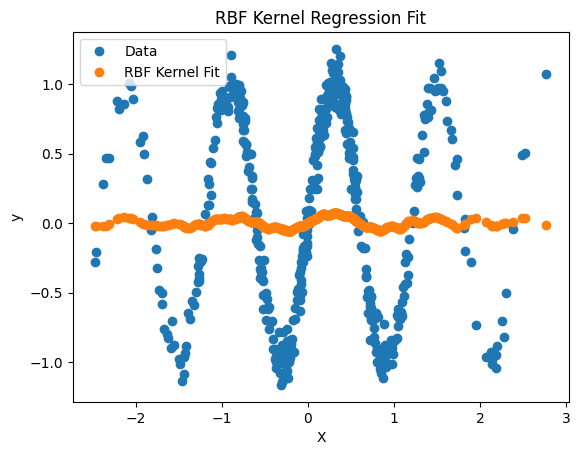

In [4]:
# plot the data and the RBF kernel regression fit
import matplotlib.pyplot as plt

plt.plot(X[:, 0], y, 'o', label='Data')
plt.plot(X[:, 0], rbf_kernel_reg(X).detach().numpy(), 'o', label='RBF Kernel Fit')
plt.title('RBF Kernel Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

In [5]:
K = rbf_kernel_torch(X, X)
assert torch.isfinite(K).all()
alpha = rbf_kernel_reg.kernel_linear.weight.detach().view(-1)
# Q_kernel = compute_Q_matrix(K, k, eps, jit=None)
# print(Q_kernel)

In [6]:
alpha.abs().min(), alpha.abs().max()

(tensor(8.6687e-06), tensor(0.0527))

In [ ]:
from typing import Optional, Any
from torch import nn
class DiagMatrixBiasKRR(nn.Module):
    def __init__(
        self,
        Q_t_init: torch.Tensor = None,
        dim: Optional[int] = None,
        t: int = 0,
        K: torch.Tensor = None,
        alpha_init: torch.Tensor = None,
        eta: float = 1e-2,
    ):
        """
        Initializes the implicit bias module for Kernel Ridge Regression,
        with a diagonal Q_t matrix.
        Args:
            Q_t_init (torch.Tensor, optional): Initial value for the Q_t vector.
                                               Should be of shape (dim,).
                                               Defaults to a zero vector if None.
            dim (int, optional): The dimension of the alpha vector (typically n, the number of samples).
                                 If Q_t_init is provided, this can be None.
        """
        super().__init__()
        if K is None:
            raise ValueError("Must provide kernel matrix K")
        # self.K = K.clone()
        # self.alpha_init = alpha_init.clone()
        self.register_buffer("K", K)
        self.register_buffer("alpha_init", alpha_init)
        self.t = t
        self.eta = eta

        if Q_t_init is not None:
            if Q_t_init.ndim != 1:
                raise ValueError(
                    f"Q_t_init should be a 1D tensor of shape ({self.dim},), but got {Q_t_init.shape}"
                )
            if dim is not None and Q_t_init.shape[0] != dim:
                raise ValueError(
                    f"dim ({dim}) does not match Q_t_init shape ({Q_t_init.shape[0]})."
                )
            self.dim = Q_t_init.shape[0]
        else:
            if dim is None:
                raise ValueError("dim must be specified if Q_t_init is not provided.")
            self.dim = dim

        assert K.shape[0] == K.shape[1], "K must be a square matrix"
        assert K.shape[0] == self.dim, "K must match the dimension of Q_t_init"

        # Initialize the Q_t matrix diagonal
        self.Q_t = nn.Parameter(
            Q_t_init
            if Q_t_init is not None
            else torch.zeros(self.dim, device=self.K.device),
            requires_grad=True,
        )
        # print("Q_t device:", self.Q_t.device)
        # print("K device:", self.K.device)
        # print("alpha_init device:", self.alpha_init.device)
        # check same device
        assert self.Q_t.device == self.K.device, "Q_t and K must be on the same device"
        assert self.alpha_init.device == self.K.device, (
            "alpha_init and K must be on the same device"
        )

    def forward(                           #  ← paste over your current forward
        self,
        alpha: torch.Tensor,
        *,
        global_step: int | None = None,
        **kwargs,
    ) -> torch.Tensor:
        # ------------------------------------------------------------------
        # 0) single source-of-truth for device & dtype
        # ------------------------------------------------------------------
        dev = self.Q_t.device
        dtype = self.Q_t.dtype

        # ------------------------------------------------------------------
        # 1) move/reshape the input alpha
        # ------------------------------------------------------------------
        if alpha.numel() == self.dim and alpha.shape != (self.dim,):
            alpha = alpha.view(self.dim)
        alpha = alpha.to(device=dev, dtype=dtype)

        # ------------------------------------------------------------------
        # 2) build C entirely on GPU with consistent dtype
        # ------------------------------------------------------------------
        scale = torch.tensor(1.0 / self.dim, device=dev, dtype=dtype)
        C = scale * (self.K.to(dev, dtype) @ self.K.to(dev, dtype))

        # ------------------------------------------------------------------
        # 3) build A and its power (GPU-safe)
        # ------------------------------------------------------------------
        I = torch.eye(self.dim, device=dev, dtype=dtype)
        A = I - 2 * self.eta * C
        A_t = torch.linalg.matrix_power(A, self.t)          # PyTorch ≥ 2.1

        # ------------------------------------------------------------------
        # 4) final pieces
        # ------------------------------------------------------------------
        omega_t = (C + torch.diag(self.Q_t)) @ A_t @ self.alpha_init.to(dev, dtype)
        quadratic_term = torch.sum(alpha.pow(2) * self.Q_t)
        linear_term = -2 * omega_t @ alpha

        # ------------------------------------------------------------------
        # 5) fail-fast asserts — remove once training is stable
        # ------------------------------------------------------------------
        for name, tensor in dict(
            alpha=alpha,
            K=self.K,
            alpha_init=self.alpha_init,
            Q_t=self.Q_t,
            C=C,
            A_t=A_t,
            omega_t=omega_t,
        ).items():
            assert tensor.device == dev,  f"{name} on {tensor.device}, expected {dev}"
            assert tensor.dtype  == dtype, f"{name} dtype {tensor.dtype}, expected {dtype}"

        return quadratic_term + linear_term

In [17]:
# from core.bias import ImplicitBiasKRR
# Estimate the quadratic form using the estimated Q from matrix ridge bias
from core.models import KernelRidgeMSELoss
from core.bias import DiagMatrixRidgeBias
from core.estimators import BiasWithAutodiffLoss, BiasWithMSE


# K = K.to(device)
# alpha = alpha.to(device)
kernel_loss_partial = partial(
    KernelRidgeMSELoss(ridge_lambda=1.), K=K, alpha=alpha
)
rbf_kernel_reg.eval()

rbf_estimator = BiasWithAutodiffLoss(
    predictive_model=rbf_kernel_reg,
    # bias_model=DiagMatrixRidgeBias(dim=N), # if alpha initialized to zeros
    bias_model=DiagMatrixBiasKRR(
        dim=N,
        alpha_init=rbf_kernel_reg.init_weights.view(-1),
        t=t,
        K=K,
        eta=eta,
    ),
    predictive_loss_fn=kernel_loss_partial,
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)
# rbf_estimator = rbf_estimator.to(device)
# for name, p in rbf_estimator.bias_model.named_parameters():
#     print(f"{name}: {p.device}")
# for name, b in rbf_estimator.bias_model.named_buffers():
#     print(f"{name}: {b.device}")

wandb_logger = WandbLogger(
    project="inductive-bias", name="kernel-bias", log_model=False
)
rbf_trainer = Trainer(
    max_epochs=100,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=150, mode="min"),
    ],
    accelerator="gpu",
    devices=n_devices,
    limit_train_batches=1,
    detect_anomaly=True,
)
# kernel_dataloader = DataLoader(TensorDataset(X, y), batch_size=N, shuffle=True)
rbf_trainer.fit(rbf_estimator, dm_sin)

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
You have turned on `Trainer(detect_anomaly=True)`. This will significantly slow down compute speed and is recommended only for model debugging.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_train_batches=1)` was configured so 1 batch per epoch will be used.
/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. 

Training: |          | 0/? [00:00<?, ?it/s]

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Error detected in torch::autograd::AccumulateGrad. Traceback of forward call that caused the error:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/in

X device: cuda:0, y device: cuda:0
Flattened params device: cuda:0
Flattened params device after to(self.device): cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
--- Debugging devices in on_before_backward (Epoch 0, Global Step 0) ---
Expected device (self.device): cuda:0
Loss tensor device: cuda:0 (Matches expected)


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [50]:
import torch
torch.manual_seed(0)

W = torch.randn(3, 3, dtype=torch.float32, device="cuda", requires_grad=True)
X = torch.randn(3, 3, dtype=torch.float64, device="cuda")  # mismatched dtype!

out = (X @ W).sum()
try:
    out.backward()
except RuntimeError as e:
    print("❌ mixed dtype triggered CPU fallback:\n", e)

# cast X -> float32, try again
out = (X.float() @ W).sum()
out.backward()      # ✅ now works

RuntimeError: expected mat1 and mat2 to have the same dtype, but got: double != float

In [29]:
# after your model and dataloader are set up:
rbf_estimator = rbf_estimator.to(device)
optimizer = rbf_estimator.configure_optimizers()
X_batch, y_batch = next(iter(dm_sin.train_dataloader()))
Xb, yb = X_batch.to(device), y_batch.to(device)

loss = rbf_estimator.training_step((Xb, yb), batch_idx=0)
optimizer.zero_grad()
loss.backward()

X device: cuda:0, y device: cuda:0
kernel reg forward
kernel_linear weight device: cuda:0
y_hat device: cuda:0, K device: cuda:0
C device: cuda:0
linear term: cuda:0
quadratic term: cuda:0


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [16]:
from collections import deque
import torch
import inspect

def dump_graph_devices(root: torch.Tensor) -> None:
    """
    Walk autograd graph starting at root.grad_fn and print the device of every
    tensor kept for backward.  Handles nodes that don't expose .saved_tensors.
    """
    seen = set()
    print(f"Dumping graph devices for {root.grad_fn}")
    q = deque([(type(root.grad_fn).__name__, root.grad_fn)])
    
    while q:
        name, fn = q.popleft()
        if fn is None or id(fn) in seen:
            continue
        seen.add(id(fn))

        # 1) tensors explicitly saved for backward
        for t in getattr(fn, "saved_tensors", ()):
            print(f"{name:<30s}  saved tensor on {t.device}")

        # 2) attributes that are tensors but not in saved_tensors
        for attr_name in dir(fn):
            if attr_name.startswith("_"):  # skip private junk
                continue
            try:
                attr = getattr(fn, attr_name)
            except RuntimeError:
                continue
            if torch.is_tensor(attr):
                print(f"{name:<30s}  attr {attr_name:>10s} on {attr.device}")

        # 3) enqueue next nodes
        for i, (next_fn, _) in enumerate(fn.next_functions):
            q.append((f"{name}->{i}", next_fn))

# ----- use it right before backward -----
dump_graph_devices(loss)

Dumping graph devices for <MseLossBackward0 object at 0x7f6b82d4f580>


In [21]:
loss.backward()


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [15]:
# TODO: is K^2 supposed to be K @ K or K @ K.T?
def compute_kernel_ridge_Q(K, eta, t):
    """
    Compute the Q matrix for kernel ridge regression.
    """
    n = K.shape[0]
    I = torch.eye(n, device=K.device)
    C = (1 / n) * K @ K + K
    A_t = torch.linalg.matrix_power(I - 2 * eta * C, t)
    A_t_inv = torch.linalg.inv(I - A_t)
    Q_t = C @ (A_t_inv - I)
    return Q_t

def compute_alpha_closed_form(K: torch.Tensor, y: torch.Tensor, Q: torch.Tensor, omega: torch.Tensor) -> torch.Tensor:
    """
    Compute the closed-form solution for alpha using the kernel matrix K.
    """
    n = K.shape[0]
    C = (1 / n) * K @ K + K

    rhs = (omega + (1 / n) * K @ y)
    lhs = C + Q
    alpha = torch.linalg.solve(lhs, rhs)
    return alpha

Q_kernel_ridge = compute_kernel_ridge_Q(K, eta=eta, t=t)

In [16]:
Q_hat_kernel_ridge = torch.diag(rbf_estimator.bias_model.Q.detach())
print("estimated Q from kernel ridge bias:\n", Q_hat_kernel_ridge)
# now estimate the quadratic form using the estimated Q from kernel bias
print("theoretical Q from kernel ridge regression:\n", Q_kernel_ridge)

In [17]:
# Compare the estimated Q from kernel bias with the one from kernel regression
print("theoretical alpha from Q bias:\n", compute_alpha_closed_form(K, y, Q_kernel_ridge, torch.zeros(N))[:25])
print("estimated alpha from Q bias:\n", compute_alpha_closed_form(K, y, Q_hat_kernel_ridge, torch.zeros(N))[:25])
print("ground truth alpha:\n", rbf_kernel_reg.kernel_linear.weight[0].detach()[:25])

### Extra